# 🏭 Análisis de Producción Industrial: Máquina Laurenti
**Autor:** Eduardo Joudzbalis | **Fecha:** Febrero 2026

## 1. Introducción
En este notebook realizaremos un análisis exploratorio de datos (EDA) sobre el rendimiento de una línea de producción de fajas para billetes.
El objetivo es limpiar los datos crudos, calcular estadísticas descriptivas e identificar el impacto de las fallas mecánicas en la productividad.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
df = pd.read_csv('FajasJnJlAg2025.csv', delimiter=';')
df.head()

,Fecha,Turno,Horario,OP,Articulo,Bandas,Cajas,Fajas x Caja,Fajas Totales,Observaciones
0,2-jun-25,M,6:00 a 14:00,10896,Credicoop,2,79,2500,197500,NaN
1,3-jun-25,M,6:00 a 14:00,10896,Credicoop,2,85,2500,212500,NaN
2,4-jun-25,M,6:00 a 14:00,10896,Credicoop,2,69,2500,172500,NaN
3,5-jun-25,M,6:00 a 14:00,10896,Credicoop,2,5,2500,12500,NaN
4,5-jun-25,M,6:00 a 14:00,10930,Credicoop,2,20,2500,50000,NaN


## 2. Limpieza de Datos (Data Cleaning)
Los datos originales provienen de registros manuales. Necesitamos:
1. Parsear las fechas que están en formato texto (ej: '2-jun-25').
2. Estandarizar los nombres de los meses.
3. Convertir columnas numéricas.

In [6]:
import pandas as pd
import numpy as np
meses_es_input = {
    'ene': '01', 'feb': '02', 'mar': '03', 'abr': '04', 'may': '05', 'jun': '06',
    'jul': '07', 'ago': '08', 'sep': '09', 'oct': '10', 'nov': '11', 'dic': '12'
}

def parsear_fecha(fecha_str):
    if pd.isna(fecha_str): return pd.NaT
    try:
        partes = str(fecha_str).split('-')
        if len(partes) == 3:
            dia, mes_txt, anio = partes
            mes_num = meses_es_input.get(mes_txt.lower(), '01')
            # Asumimos que si el año tiene 2 dígitos es 20xx
            anio_completo = '20' + anio if len(anio) == 2 else anio
            return pd.to_datetime(f"{anio_completo}-{mes_num}-{dia.zfill(2)}")
        return pd.NaT
    except:
        return pd.NaT
df['Fecha_dt'] = df['Fecha'].apply(parsear_fecha)
mapa_meses_output = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
    7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
df['Mes_Nombre'] = df['Fecha_dt'].dt.month.map(mapa_meses_output)

df['Fajas Totales'] = pd.to_numeric(df['Fajas Totales'], errors='coerce')


print(df[['Fecha', 'Fecha_dt', 'Mes_Nombre']].head())
df.info()

      Fecha   Fecha_dt Mes_Nombre
0  2-jun-25 2025-06-02      Junio
1  3-jun-25 2025-06-03      Junio
2  4-jun-25 2025-06-04      Junio
3  5-jun-25 2025-06-05      Junio
4  5-jun-25 2025-06-05      Junio
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha          71 non-null     object        
 1   Turno          71 non-null     object        
 2   Horario        71 non-null     object        
 3   OP             71 non-null     int64         
 4   Articulo       71 non-null     object        
 5   Bandas         71 non-null     int64         
 6   Cajas          71 non-null     int64         
 7   Fajas x Caja   71 non-null     int64         
 8   Fajas Totales  71 non-null     int64         
 9   Observaciones  14 non-null     object        
 10  Fecha_dt       71 non-null     datetime64[ns]
 11  Mes_Nombre     71 non-nul

## 3. Categorización de Fallas
La columna `Observaciones` contiene texto libre. Vamos a crear una nueva variable categórica para clasificar los tipos de interrupciones (Sensores, Bobinas, Contactores, etc.).

In [7]:
df['Observaciones'] = df['Observaciones'].fillna('')

def categorizar_falla(obs):
    obs = str(obs).lower()
    if obs == '' or obs == 'nan': return 'Sin Incidencias'
    if 'sensor' in obs: return 'Falla Sensor'
    if 'bobina' in obs: return 'Falla Bobina'
    if 'contactor' in obs: return 'Falla Contactor'
    if 'adhesivo' in obs: return 'Falla Adhesivo'
    if 'humedad' in obs: return 'Problemas Humedad'
    return 'Otras'

df['Categoria_Falla'] = df['Observaciones'].apply(categorizar_falla)

# Conteo de fallas
conteo = df['Categoria_Falla'].value_counts()
conteo

,count
Categoria_Falla,
Sin Incidencias,57
Falla Contactor,4
Falla Sensor,3
Falla Adhesivo,3
Otras,2
Problemas Humedad,1
Falla Bobina,1


## 4. Análisis Estadístico y KPIs
Calculamos el promedio de producción diario y comparamos el rendimiento entre días normales y días con fallas.

In [8]:
# Estadísticas Generales
promedio = df['Fajas Totales'].mean()
desviacion = df['Fajas Totales'].std()

print(f"--- KPIs Globales ---")
print(f"Promedio Diario: {promedio:,.0f} unidades")
print(f"Desviación Estándar: {desviacion:,.0f} unidades")

# Impacto de Fallas
prod_sin = df[df['Categoria_Falla'] == 'Sin Incidencias']['Fajas Totales'].mean()
prod_con = df[df['Categoria_Falla'] != 'Sin Incidencias']['Fajas Totales'].mean()
impacto = ((prod_sin - prod_con) / prod_sin) * 100

print(f"\n--- Costo de No Calidad ---")
print(f"Producción Objetivo (Sin Fallas): {prod_sin:,.0f}")
print(f"Producción Real (Con Fallas): {prod_con:,.0f}")
print(f"Caída de Rendimiento: {impacto:.2f}%")

--- KPIs Globales ---
Promedio Diario: 163,620 unidades
Desviación Estándar: 62,429 unidades

--- Costo de No Calidad ---
Producción Objetivo (Sin Fallas): 171,904
Producción Real (Con Fallas): 129,893
Caída de Rendimiento: 24.44%


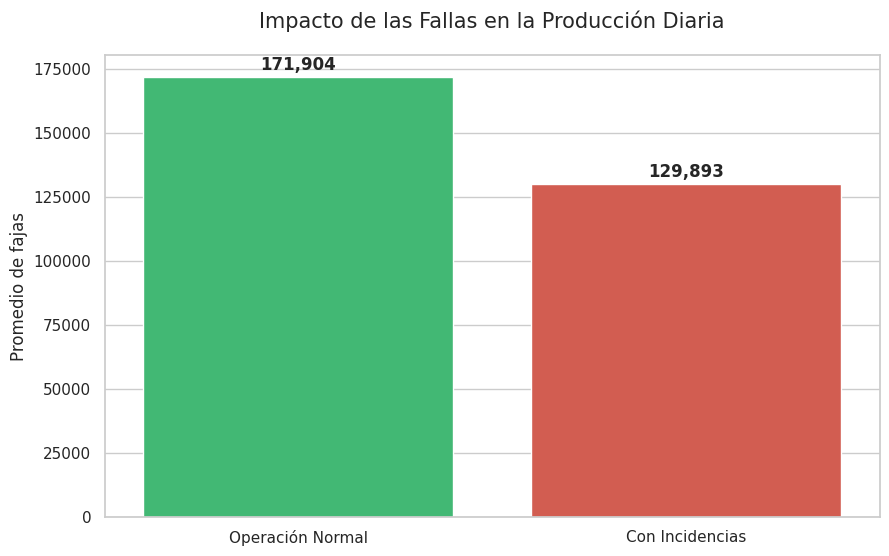

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# RE-DEFINICIÓN DE VARIABLES (Para asegurar que existan)
prod_sin = df[df['Categoria_Falla'] == 'Sin Incidencias']['Fajas Totales'].mean()
prod_con = df[df['Categoria_Falla'] != 'Sin Incidencias']['Fajas Totales'].mean()

# Configuración de estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

categorias = ['Operación Normal', 'Con Incidencias']
valores = [prod_sin, prod_con]

# CÓDIGO CORREGIDO: Asignamos x a hue y desactivamos la leyenda para quitar el Warning
ax = sns.barplot(x=categorias, y=valores, hue=categorias, palette=['#2ecc71', '#e74c3c'], legend=False)

# Etiquetas de datos (IDEM)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Impacto de las Fallas en la Producción Diaria', fontsize=15, pad=20)
plt.ylabel('Promedio de fajas')
plt.show()